# Fase 3 — Clasificación supervisada

**Curso:** MCDI504 — Machine Learning I  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial  
**Integrante(s):** *Jennifer Nilo, Patricio Núñez*  
**Fecha:** 20 de agosto de 2026  
**Repositorio:** *https://github.com/pnunezcarreno/machinelearning1*  

---

## Propósito del notebook

Este notebook implementa y evalúa modelos de **clasificación supervisada** sobre el dataset Titanic. El problema analítico consiste en predecir la variable binaria `survived` a partir de características disponibles de cada pasajero.

El flujo deja trazabilidad entre la descripción de los datos, el análisis exploratorio, la preparación, el ajuste de **k-NN**, **árbol de decisión**, **SVM**, **Naive Bayes** y tres arquitecturas de **redes neuronales MLP** (una, dos y tres capas ocultas), la evaluación comparativa y las conclusiones preliminares.

La preparación se implementa mediante `Pipeline` y `ColumnTransformer` para que imputación, codificación y estandarización se ajusten únicamente con datos de entrenamiento, reduciendo el riesgo de fuga de información (Scikit-learn developers, n.d.-a).

## Índice

1. Descripción del dataset y problema de clasificación
2. Análisis exploratorio inicial
3. Preparación para clasificación
4. Modelo k-NN
5. Modelo de árbol de decisión
6. Modelo SVM
7. Modelo Naive Bayes
8. Modelos de Redes Neuronales y su Evaluación
   - 8.1 Red Neuronal con Una Capa Oculta
   - 8.2 Red Neuronal con Dos Capas Ocultas
   - 8.3 Red Neuronal con Tres Capas Ocultas
9. Evaluación preliminar comparativa
10. Conclusiones preliminares
11. Referencias
12. Anexos y evidencias exportables

### Correspondencia con la rúbrica

| Sección | Evidencia |
|---|---|
| 1–3 | Dataset, objetivo, predictores, calidad, selección, partición y justificación |
| 4 | Configuración, ejecución e interpretación de k-NN |
| 5 | Configuración, ejecución e interpretación del árbol |
| 6 | Configuración, ejecución e interpretación de SVM |
| 7 | Supuestos, configuración, ejecución e interpretación de Naive Bayes |
| 8 | Implementación y comparación de MLP con una, dos y tres capas ocultas |
| 9 | Matrices de confusión, métricas y comparación de todos los modelos |
| 10 | Síntesis sustentada en resultados |
| 11 | Fuentes docentes, oficiales y académicas |
| 12 | Tablas, figuras y resultados complementarios |


In [2]:
# 0. Configuración general
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn import __version__ as sklearn_version
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
TEST_SIZE = 0.20

RESULTS_DIR = Path("resultados_fase3")
FIGURES_DIR = RESULTS_DIR / "figuras"
TABLES_DIR = RESULTS_DIR / "tablas"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Entorno listo.")
print("Versión de scikit-learn:", sklearn_version)

Entorno listo.
Versión de scikit-learn: 1.6.1


# 1. Descripción del dataset y problema de clasificación

Se utiliza el dataset **Titanic** distribuido en el repositorio público `seaborn-data`. Cada fila representa un registro de pasajero y la variable `survived` indica si sobrevivió (`1`) o no (`0`).

El problema corresponde a una **clasificación binaria supervisada**.

### Variable objetivo
- **`survived`**: `0 = no sobrevivió`, `1 = sobrevivió`.

### Variables predictoras candidatas
- `pclass`: clase del pasaje. (1 = Primera, 2 = Segunda, 3 = Tercera)
- `sex`: sexo registrado. (male, female)
- `age`: edad.
- `sibsp`: hermanos/cónyuges a bordo.
- `parch`: padres/hijos a bordo.
- `fare`: tarifa.
- `embarked`: puerto de embarque. (C = Cherbourg, Q = Queenstown, S = Southampton)

### Otras variables
*   `class`: Clase del pasaje (First, Second, Third). Similar a `pclass`.
*   `who`: Género (man, woman, child). Similar a `sex`.
*   `adult_male`: Indica si es un hombre adulto (True/False).
*   `deck`: Cubierta donde se encontraba la cabina del pasajero.
*   `embark_town`: Ciudad de embarque (Southampton, Cherbourg, Queenstown). Similar a `embarked`.
*   `alive`: Si el pasajero sobrevivió (yes/no). Similar a `survived`.
*   `alone`: Si el pasajero viajaba solo (True/False).

In [3]:
# 1.1 Carga del dataset
# Cargar el dataset del Titanic
titanic_df = sns.load_dataset('titanic')


print(f"Dimensiones: {titanic_df.shape[0]} filas x {titanic_df.shape[1]} columnas")
display(titanic_df.head())

Dimensiones: 891 filas x 15 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# 1.2 Diccionario resumido de variables
data_dictionary = pd.DataFrame({
    "Variable": [
        "survived","pclass","sex","age","sibsp","parch","fare","embarked",
        "class","who","adult_male","deck","embark_town","alive","alone"
    ],
    "Descripción": [
        "Objetivo: supervivencia (0=no, 1=sí)",
        "Clase del pasaje","Sexo registrado","Edad","Hermanos/cónyuges",
        "Padres/hijos","Tarifa","Puerto de embarque",
        "Texto equivalente a pclass","Derivada de sexo/edad","Derivada de sexo/edad",
        "Cubierta/cabina","Texto equivalente a embarked","Texto equivalente a survived",
        "Derivada de sibsp/parch"
    ],
    "Decisión inicial": [
        "Objetivo","Usar","Usar","Usar","Usar","Usar","Usar","Usar",
        "Excluir: redundante","Excluir: derivada","Excluir: derivada",
        "Excluir: alta ausencia","Excluir: redundante","Excluir: fuga de información",
        "Excluir: derivada"
    ]
})
display(data_dictionary)

,Variable,Descripción,Decisión inicial
0,survived,"Objetivo: supervivencia (0=no, 1=sí)",Objetivo
1,pclass,Clase del pasaje,Usar
2,sex,Sexo registrado,Usar
3,age,Edad,Usar
4,sibsp,Hermanos/cónyuges,Usar
5,parch,Padres/hijos,Usar
6,fare,Tarifa,Usar
7,embarked,Puerto de embarque,Usar
8,class,Texto equivalente a pclass,Excluir: redundante
9,who,Derivada de sexo/edad,Excluir: derivada


In [5]:
# 1.3 Revisión inicial de calidad
quality_table = pd.DataFrame({
    "tipo": titanic_df.dtypes.astype(str),
    "nulos": titanic_df.isna().sum(),
    "porcentaje_nulos": titanic_df.isna().mean() * 100,
    "valores_unicos": titanic_df.nunique(dropna=True)
}).sort_values("porcentaje_nulos", ascending=False)

display(quality_table)

print(f"Filas duplicadas exactas: {titanic_df.duplicated().sum()}")
print(
    "No se eliminan automáticamente porque el dataset no contiene un identificador único; "
    "filas iguales en estas variables podrían representar pasajeros distintos."
)

,tipo,nulos,porcentaje_nulos,valores_unicos
deck,category,688,77.2166,7
age,float64,177,19.8653,88
embarked,object,2,0.2245,3
embark_town,object,2,0.2245,3
sex,object,0,0.0000,2
pclass,int64,0,0.0000,3
survived,int64,0,0.0000,2
fare,float64,0,0.0000,248
parch,int64,0,0.0000,7
sibsp,int64,0,0.0000,7


Filas duplicadas exactas: 107
No se eliminan automáticamente porque el dataset no contiene un identificador único; filas iguales en estas variables podrían representar pasajeros distintos.


### Justificación de la selección de variables

Se conservarán `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare` y `embarked`.

Se excluyen:

- **`alive`**: codifica directamente la variable objetivo y produciría fuga de información.
- **`class`** y **`embark_town`**: redundantes con `pclass` y `embarked`.
- **`who`** y **`adult_male`**: variables derivadas principalmente de sexo y edad.
- **`alone`**: derivada de `sibsp` y `parch`.
- **`deck`**: presenta una proporción muy alta de valores faltantes.

La selección busca conservar información relevante sin duplicar atributos ni entregar al modelo información derivada del resultado.

# 2. Análisis exploratorio inicial

El EDA busca evidenciar:

1. distribución de clases;
2. calidad de datos;
3. patrones iniciales en variables relevantes;
4. posibles desequilibrios que influyan en la evaluación.

La selección de hiperparámetros se realizará mediante **F1 de la clase positiva** en validación cruzada. La evaluación final incluirá accuracy, precision, recall, F1, ROC-AUC y matriz de confusión (Scikit-learn developers, n.d.-b).

,frecuencia,porcentaje
survived,,
0,549,61.6162
1,342,38.3838


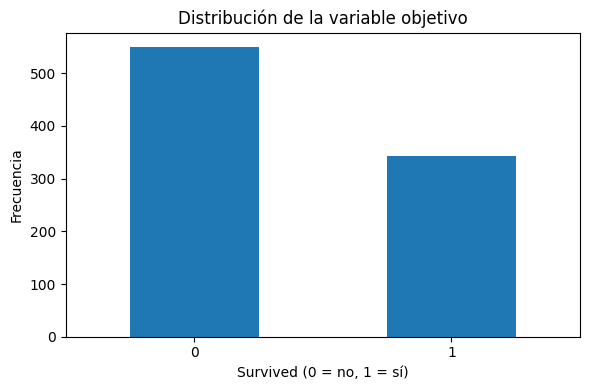

**Lectura:** la clase menos frecuente representa aproximadamente **38.4%** de los registros. Se usará partición estratificada y métricas adicionales a accuracy.

In [6]:
# 2.1 Distribución de clases
class_distribution = (
    titanic_df["survived"].value_counts().sort_index()
    .rename_axis("survived").to_frame("frecuencia")
)
class_distribution["porcentaje"] = (
    class_distribution["frecuencia"] / class_distribution["frecuencia"].sum() * 100
)
display(class_distribution)

plt.figure(figsize=(6,4))
class_distribution["frecuencia"].plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Survived (0 = no, 1 = sí)")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_distribucion_clases.png", dpi=160, bbox_inches="tight")
plt.show()

minority_pct = class_distribution["porcentaje"].min()
display(Markdown(
    f"**Lectura:** la clase menos frecuente representa aproximadamente **{minority_pct:.1f}%** "
    "de los registros. Se usará partición estratificada y métricas adicionales a accuracy."
))

In [7]:
# 2.2 Frecuencias y tasas por variables relevantes
survival_by_sex = (
    titanic_df.groupby("sex", observed=False)["survived"]
    .agg(["count","mean"])
    .rename(columns={"count":"n","mean":"tasa_supervivencia"})
)
survival_by_pclass = (
    titanic_df.groupby("pclass", observed=False)["survived"]
    .agg(["count","mean"])
    .rename(columns={"count":"n","mean":"tasa_supervivencia"})
)
survival_by_embarked = (
    titanic_df.groupby("embarked", observed=False)["survived"]
    .agg(["count","mean"])
    .rename(columns={"count":"n","mean":"tasa_supervivencia"})
)

print("Por sexo:")
display(survival_by_sex)
print("Por clase:")
display(survival_by_pclass)
print("Por puerto:")
display(survival_by_embarked)

Por sexo:


,n,tasa_supervivencia
sex,,
female,314,0.7420
male,577,0.1889


Por clase:


,n,tasa_supervivencia
pclass,,
1,216,0.6296
2,184,0.4728
3,491,0.2424


Por puerto:


,n,tasa_supervivencia
embarked,,
C,168,0.5536
Q,77,0.3896
S,644,0.3370


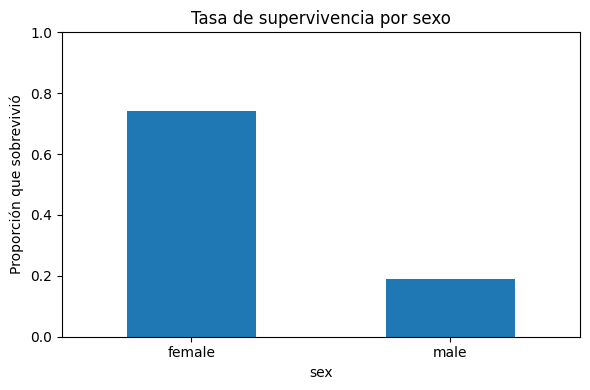

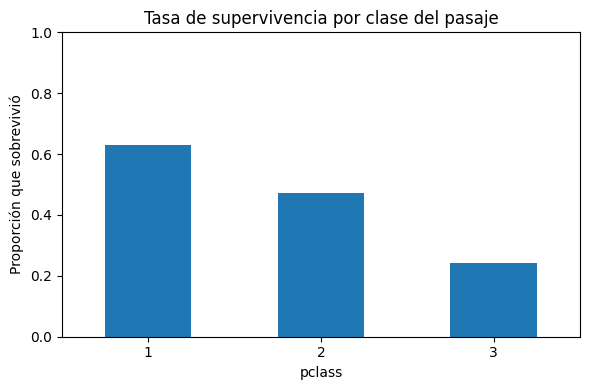

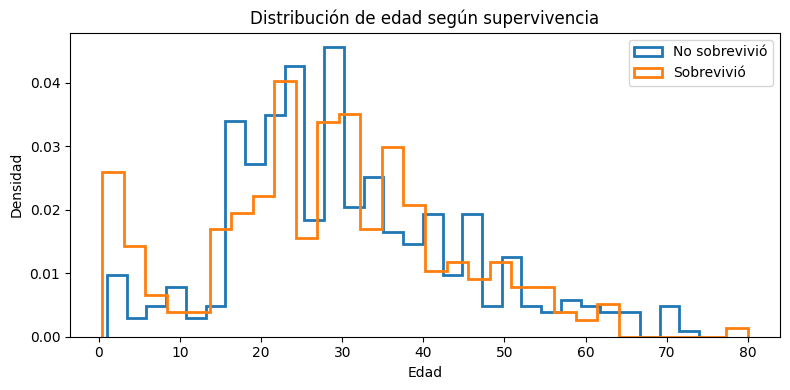

In [8]:
# 2.3 Visualizaciones exploratorias
survival_by_sex = titanic_df.groupby("sex", dropna=False)["survived"].mean().to_frame("tasa_supervivencia")
plt.figure(figsize=(6,4))
survival_by_sex["tasa_supervivencia"].plot(kind="bar")
plt.title("Tasa de supervivencia por sexo")
plt.ylabel("Proporción que sobrevivió")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_supervivencia_por_sexo.png", dpi=160, bbox_inches="tight")
plt.show()

survival_by_pclass = titanic_df.groupby("pclass", dropna=False)["survived"].mean().to_frame("tasa_supervivencia")
plt.figure(figsize=(6,4))
survival_by_pclass["tasa_supervivencia"].plot(kind="bar")
plt.title("Tasa de supervivencia por clase del pasaje")
plt.ylabel("Proporción que sobrevivió")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_supervivencia_por_pclass.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,4))
for survived_value, label in [(0, "No sobrevivió"), (1, "Sobrevivió")]:
    ages = titanic_df.loc[titanic_df["survived"] == survived_value, "age"].dropna()
    plt.hist(ages, bins=30, density=True, histtype="step", linewidth=2, label=label)
plt.title("Distribución de edad según supervivencia")
plt.xlabel("Edad")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_edad_por_supervivencia.png", dpi=160, bbox_inches="tight")
plt.show()

In [9]:
# 2.4 Síntesis automática del EDA
female_rate = survival_by_sex.loc["female","tasa_supervivencia"]
male_rate = survival_by_sex.loc["male","tasa_supervivencia"]
first_rate = survival_by_pclass.loc[1,"tasa_supervivencia"]
third_rate = survival_by_pclass.loc[3,"tasa_supervivencia"]
age_missing = titanic_df["age"].isna().mean()
deck_missing = titanic_df["deck"].isna().mean()

display(Markdown(f"""
### Hallazgos preliminares

- Supervivencia observada en `female`: **{female_rate:.1%}**; en `male`: **{male_rate:.1%}**.
- Supervivencia observada en primera clase: **{first_rate:.1%}**; en tercera clase: **{third_rate:.1%}**.
- `age` presenta aproximadamente **{age_missing:.1%}** de valores faltantes.
- `deck` presenta aproximadamente **{deck_missing:.1%}** de valores faltantes.
- Los patrones son descriptivos y sirven para orientar la preparación; no se interpretan como relaciones causales.
"""))


### Hallazgos preliminares

- Supervivencia observada en `female`: **74.2%**; en `male`: **18.9%**.
- Supervivencia observada en primera clase: **63.0%**; en tercera clase: **24.2%**.
- `age` presenta aproximadamente **19.9%** de valores faltantes.
- `deck` presenta aproximadamente **77.2%** de valores faltantes.
- Los patrones son descriptivos y sirven para orientar la preparación; no se interpretan como relaciones causales.


# 3. Preparación para clasificación

**Predictoras:** `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`  
**Objetivo:** `survived`

La partición se realiza **antes** de ajustar imputadores, codificadores o escaladores.

### Estrategia

- Numéricas: imputación por mediana.
- Categóricas: imputación por moda + One-Hot Encoding.
- k-NN, SVM y redes neuronales MLP: estandarización de variables numéricas.
- Árbol y Gaussian Naive Bayes: sin escalado numérico.

El modelo k-NN destaca que el escalado evita que una variable domine la distancia y recomienda seleccionar `k` mediante validación cruzada (Ruete, 2026b). Para SVM, el escalado debe ajustarse con entrenamiento y aplicarse con los mismos parámetros a validación y prueba (Ruete, 2026c). En las redes neuronales MLP también se utiliza el preprocesamiento escalado, ya que la optimización iterativa es sensible a diferencias importantes de escala entre variables (Ruete, 2026e).

In [10]:
# 3.1 Selección y partición entrenamiento/prueba
selected_features = ["pclass","sex","age","sibsp","parch","fare","embarked"]
X = titanic_df[selected_features].copy()
y = titanic_df["survived"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

split_summary = pd.DataFrame({
    "conjunto":["Entrenamiento","Prueba"],
    "filas":[len(X_train),len(X_test)],
    "porcentaje":[len(X_train)/len(X),len(X_test)/len(X)],
    "tasa_clase_positiva":[y_train.mean(),y_test.mean()]
})
display(split_summary)

assert set(X_train.index).isdisjoint(set(X_test.index))
print("Partición verificada: train y test no comparten filas.")

,conjunto,filas,porcentaje,tasa_clase_positiva
0,Entrenamiento,712,0.7991,0.3834
1,Prueba,179,0.2009,0.3855


Partición verificada: train y test no comparten filas.


In [11]:
# 3.2 Preprocesadores y validación cruzada
numeric_features = ["pclass","age","sibsp","parch","fare"]
categorical_features = ["sex","embarked"]

numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_scaled = ColumnTransformer([
    ("num", numeric_scaled, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
], verbose_feature_names_out=False)

preprocessor_unscaled = ColumnTransformer([
    ("num", numeric_unscaled, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
], verbose_feature_names_out=False)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Preprocesadores definidos.")

Preprocesadores definidos.


In [12]:
# 3.3 Funciones auxiliares de ajuste y evaluación
model_searches = {}
model_predictions = {}
model_scores = {}
model_metrics = []
classification_reports = {}

def continuous_score(estimator, X_data):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_data)[:,1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X_data)
    return estimator.predict(X_data)

def fit_and_evaluate(name, pipeline, param_grid):
    search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=cv_strategy,
        n_jobs=1,
        return_train_score=True,
        refit=True
    )
    search.fit(X_train, y_train)

    y_pred = search.predict(X_test)
    y_score = continuous_score(search.best_estimator_, X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    i = search.best_index_
    row = {
        "Modelo": name,
        "F1_CV_train": search.cv_results_["mean_train_score"][i],
        "F1_CV_validación": search.cv_results_["mean_test_score"][i],
        "Accuracy_test": accuracy_score(y_test, y_pred),
        "Precision_test": precision_score(y_test, y_pred, zero_division=0),
        "Recall_test": recall_score(y_test, y_pred, zero_division=0),
        "F1_test": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC_test": roc_auc_score(y_test, y_score),
        "VN": tn, "FP": fp, "FN": fn, "VP": tp
    }

    model_searches[name] = search
    model_predictions[name] = y_pred
    model_scores[name] = y_score
    model_metrics.append(row)

    classification_reports[name] = pd.DataFrame(
        classification_report(
            y_test, y_pred,
            target_names=["No sobrevivió","Sobrevivió"],
            output_dict=True, zero_division=0
        )
    ).T

    print(f"Modelo: {name}")
    print("Mejores hiperparámetros:")
    display(pd.DataFrame([search.best_params_]))
    print("Métricas en prueba:")
    display(pd.DataFrame([row]).set_index("Modelo"))
    return search

# 4. Modelo k-NN

k-NN clasifica una observación a partir de sus vecinos más cercanos. Su comportamiento depende del número de vecinos, la distancia y el escalado de las variables (Ruete, 2026b; Scikit-learn developers, n.d.-c).

### Parámetros evaluados
- `n_neighbors`: 3, 5, 7, 9, 11, 15.
- `weights`: `uniform`, `distance`.
- `p`: 1 (Manhattan), 2 (Euclidiana).
- Criterio de selección: F1 en validación cruzada estratificada.

In [13]:
knn_pipeline = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", KNeighborsClassifier())
])

knn_grid = {
    "model__n_neighbors":[3,5,7,9,11,15],
    "model__weights":["uniform","distance"],
    "model__p":[1,2]
}

knn_search = fit_and_evaluate("KNN", knn_pipeline, knn_grid)

Modelo: KNN
Mejores hiperparámetros:


,model__n_neighbors,model__p,model__weights
0,3,1,uniform


Métricas en prueba:


,F1_CV_train,F1_CV_validación,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,VN,FP,FN,VP
Modelo,,,,,,,,,,,
KNN,0.8291,0.7406,0.8156,0.7727,0.7391,0.7556,0.8531,95,15,18,51


,k,mejor_F1_CV
0,3,0.7406
1,5,0.7344
2,7,0.7256
3,9,0.7381
4,11,0.7298
5,15,0.7384


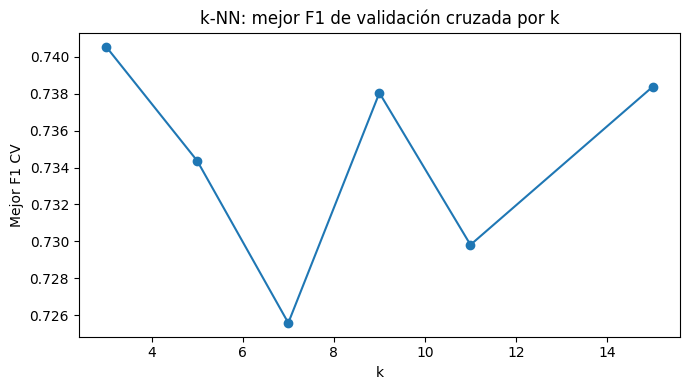

**Interpretación:** la mejor configuración usa `k=3`, `weights='uniform'` y `p=1`. La selección se sustenta en validación cruzada, no en un valor de k fijado arbitrariamente.

In [14]:
# 4.1 Evidencia de selección de k
knn_cv = pd.DataFrame(knn_search.cv_results_)
knn_cv["k"] = knn_cv["param_model__n_neighbors"].astype(int)
knn_k_summary = (
    knn_cv.groupby("k", as_index=False)["mean_test_score"].max()
    .rename(columns={"mean_test_score":"mejor_F1_CV"})
)
display(knn_k_summary)

plt.figure(figsize=(7,4))
plt.plot(knn_k_summary["k"], knn_k_summary["mejor_F1_CV"], marker="o")
plt.title("k-NN: mejor F1 de validación cruzada por k")
plt.xlabel("k")
plt.ylabel("Mejor F1 CV")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_knn_seleccion_k.png", dpi=160, bbox_inches="tight")
plt.show()

best_knn = knn_search.best_estimator_.named_steps["model"]
display(Markdown(
    f"**Interpretación:** la mejor configuración usa `k={best_knn.n_neighbors}`, "
    f"`weights='{best_knn.weights}'` y `p={best_knn.p}`. "
    "La selección se sustenta en validación cruzada, no en un valor de k fijado arbitrariamente."
))

# 5. Modelo de árbol de decisión

Los árboles de decisión particionan el espacio mediante reglas jerárquicas. La profundidad controla parte importante de su complejidad: demasiada profundidad puede aumentar el sobreajuste, mientras que un árbol demasiado simple puede subajustar (Ruete, 2026a).

### Parámetros evaluados
- `criterion`: `gini`, `entropy`.
- `max_depth`: 3, 4, 5, 6, 8.
- `min_samples_leaf`: 1, 3, 5, 10.
- Criterio de selección: F1 en validación cruzada.

In [15]:
tree_pipeline = Pipeline([
    ("prep", preprocessor_unscaled),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

tree_grid = {
    "model__criterion":["gini","entropy"],
    "model__max_depth":[3,4,5,6,8],
    "model__min_samples_leaf":[1,3,5,10]
}

tree_search = fit_and_evaluate("Árbol de decisión", tree_pipeline, tree_grid)

Modelo: Árbol de decisión
Mejores hiperparámetros:


,model__criterion,model__max_depth,model__min_samples_leaf
0,entropy,8,1


Métricas en prueba:


,F1_CV_train,F1_CV_validación,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,VN,FP,FN,VP
Modelo,,,,,,,,,,,
Árbol de decisión,0.8600,0.7440,0.7933,0.7963,0.6232,0.6992,0.8073,99,11,26,43


Profundidad efectiva: 8
Número de hojas: 52


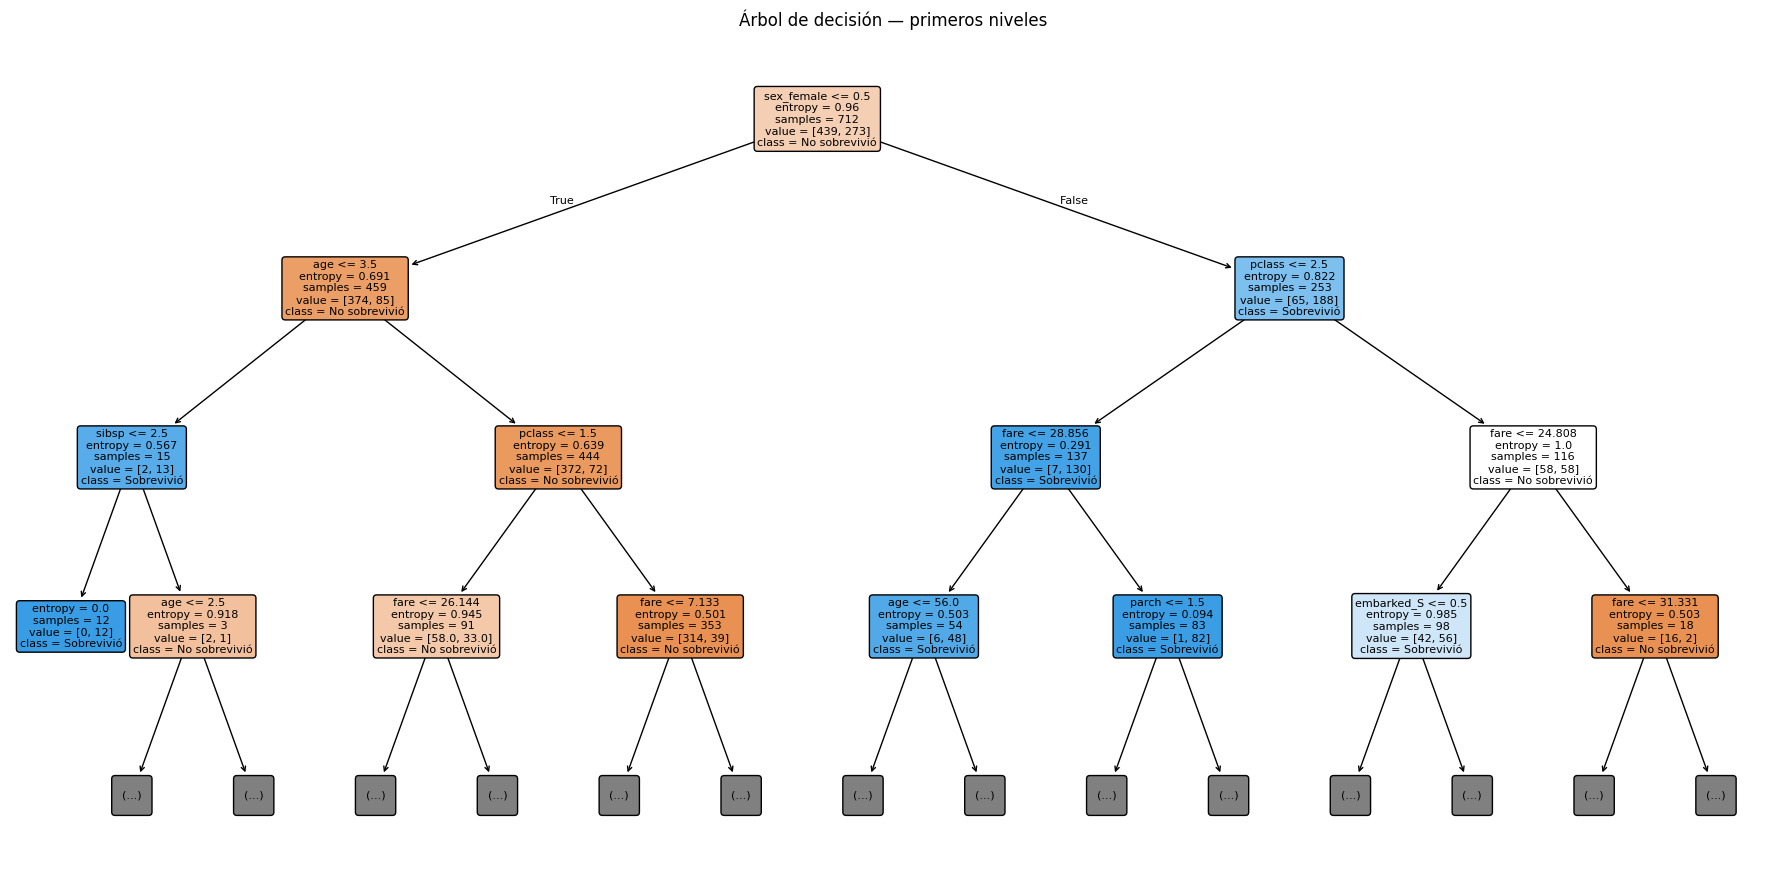

,variable_transformada,importancia
5,sex_female,0.3568
4,fare,0.2502
1,age,0.1705
0,pclass,0.1645
2,sibsp,0.0320
9,embarked_S,0.0196
3,parch,0.0064
6,sex_male,0.0000
7,embarked_C,0.0000
8,embarked_Q,0.0000


**Interpretación:** el árbol tiene profundidad **8** y **52** hojas. La brecha F1 train-validación es **0.116**, una señal útil para vigilar sobreajuste junto con la complejidad del árbol.

In [16]:
# 5.1 Complejidad, visualización e importancia de variables
best_tree_pipeline = tree_search.best_estimator_
tree_preprocessor = best_tree_pipeline.named_steps["prep"]
tree_model = best_tree_pipeline.named_steps["model"]
tree_feature_names = tree_preprocessor.get_feature_names_out()

print("Profundidad efectiva:", tree_model.get_depth())
print("Número de hojas:", tree_model.get_n_leaves())

plt.figure(figsize=(18,9))
plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    class_names=["No sobrevivió","Sobrevivió"],
    filled=True, rounded=True, max_depth=3, fontsize=8
)
plt.title("Árbol de decisión — primeros niveles")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_arbol_decision.png", dpi=160, bbox_inches="tight")
plt.show()

importance_df = pd.DataFrame({
    "variable_transformada":tree_feature_names,
    "importancia":tree_model.feature_importances_
}).sort_values("importancia", ascending=False)
display(importance_df.head(10))

tree_row = next(x for x in model_metrics if x["Modelo"] == "Árbol de decisión")
gap_tree = tree_row["F1_CV_train"] - tree_row["F1_CV_validación"]
display(Markdown(
    f"**Interpretación:** el árbol tiene profundidad **{tree_model.get_depth()}** y "
    f"**{tree_model.get_n_leaves()}** hojas. La brecha F1 train-validación es **{gap_tree:.3f}**, "
    "una señal útil para vigilar sobreajuste junto con la complejidad del árbol."
))

# 6. Modelo SVM

SVM busca una frontera que separe las clases maximizando el margen. El kernel RBF permite fronteras no lineales y los hiperparámetros `C` y `gamma` controlan el compromiso entre ajuste y generalización (Ruete, 2026c; Scikit-learn developers, n.d.-d).

### Parámetros evaluados
- Kernel lineal: `C` = 0.1, 1, 10.
- Kernel RBF: `C` = 0.1, 1, 10; `gamma` = `scale`, `auto`.
- Preprocesamiento con estandarización.

In [17]:
svm_pipeline = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", SVC())
])

svm_grid = [
    {"model__kernel":["linear"], "model__C":[0.1,1,10]},
    {"model__kernel":["rbf"], "model__C":[0.1,1,10], "model__gamma":["scale","auto"]}
]

svm_search = fit_and_evaluate("SVM", svm_pipeline, svm_grid)

Modelo: SVM
Mejores hiperparámetros:


,model__C,model__gamma,model__kernel
0,1,auto,rbf


Métricas en prueba:


,F1_CV_train,F1_CV_validación,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,VN,FP,FN,VP
Modelo,,,,,,,,,,,
SVM,0.7692,0.7558,0.8268,0.8167,0.7101,0.7597,0.8411,99,11,20,49


In [18]:
# 6.1 Diagnóstico del mejor SVM
best_svm = svm_search.best_estimator_.named_steps["model"]
svm_details = pd.DataFrame({
    "Elemento":["kernel","C","gamma","vectores_soporte_clase_0","vectores_soporte_clase_1"],
    "Valor":[best_svm.kernel,best_svm.C,best_svm.gamma,int(best_svm.n_support_[0]),int(best_svm.n_support_[1])]
})
display(svm_details)

display(Markdown(
    "**Interpretación:** el modelo se ajusta sobre variables estandarizadas. "
    "Los vectores de soporte son las observaciones críticas para definir la frontera de decisión."
))

,Elemento,Valor
0,kernel,rbf
1,C,1
2,gamma,auto
3,vectores_soporte_clase_0,168
4,vectores_soporte_clase_1,160


**Interpretación:** el modelo se ajusta sobre variables estandarizadas. Los vectores de soporte son las observaciones críticas para definir la frontera de decisión.

# 7. Modelo Naive Bayes

Naive Bayes es un clasificador probabilístico basado en el teorema de Bayes y en independencia condicional entre predictores. **Gaussian Naive Bayes** modela los predictores continuos con distribuciones normales condicionadas a la clase (Ruete, 2026d).

El dataset mezcla variables continuas, discretas y binarias codificadas, por lo que GaussianNB se utiliza como **aproximación probabilística inicial** y sus supuestos deben considerarse al interpretar el desempeño.

### Parámetro evaluado
- `var_smoothing`: valores entre `1e-11` y `1e-7`.

In [19]:
nb_pipeline = Pipeline([
    ("prep", preprocessor_unscaled),
    ("model", GaussianNB())
])

nb_grid = {"model__var_smoothing":np.logspace(-11,-7,5)}

nb_search = fit_and_evaluate("Naive Bayes", nb_pipeline, nb_grid)

Modelo: Naive Bayes
Mejores hiperparámetros:


,model__var_smoothing
0,0.0000


Métricas en prueba:


,F1_CV_train,F1_CV_validación,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,VN,FP,FN,VP
Modelo,,,,,,,,,,,
Naive Bayes,0.7304,0.7355,0.7877,0.7385,0.6957,0.7164,0.8191,93,17,21,48


In [20]:
# 7.1 Parámetros y probabilidades previas
best_nb = nb_search.best_estimator_.named_steps["model"]
nb_details = pd.DataFrame({
    "Elemento":["var_smoothing","prior clase 0","prior clase 1"],
    "Valor":[best_nb.var_smoothing,best_nb.class_prior_[0],best_nb.class_prior_[1]]
})
display(nb_details)

display(Markdown(
    "**Interpretación:** Naive Bayes ofrece una referencia probabilística eficiente, "
    "pero su supuesto de independencia condicional y la aproximación gaussiana no tienen por qué cumplirse exactamente."
))

,Elemento,Valor
0,var_smoothing,0.0000
1,prior clase 0,0.6166
2,prior clase 1,0.3834


**Interpretación:** Naive Bayes ofrece una referencia probabilística eficiente, pero su supuesto de independencia condicional y la aproximación gaussiana no tienen por qué cumplirse exactamente.

# 8. Modelos de Redes Neuronales y su Evaluación

Se implementan tres **Perceptrones Multicapa (MLP)** con distinta profundidad. El objetivo es evaluar si aumentar el número de capas ocultas aporta mejoras sobre el mismo problema de clasificación.

Para mantener una comparación controlada, las tres redes utilizan:

- `activation='relu'`
- `solver='adam'`
- `max_iter=500`
- `random_state=42`
- variables numéricas estandarizadas mediante el mismo `preprocessor_scaled`
- selección y evaluación mediante el mismo esquema de validación cruzada estratificada utilizado en los modelos anteriores

Se evaluaron tres arquitecturas de Perceptrón Multicapa (MLP) con una, dos y tres capas ocultas, con el objetivo de analizar cómo la profundidad de la red influye en el desempeño de clasificación y en su capacidad de generalización.

- una capa oculta: (100,)
- dos capas ocultas: (100, 50)
- tres capas ocultas: (100, 50, 25)

El aumento de profundidad incrementa la capacidad representacional del modelo, pero no garantiza una mejora en datos no vistos y puede aumentar el riesgo de sobreajuste y el costo computacional (Ruete, 2026e).

### 8.1 Red Neuronal con Una Capa Oculta

La primera arquitectura utiliza una única capa oculta con **100 neuronas**:

`Entrada → 100 → Salida`

Esta configuración constituye la referencia más simple entre las tres redes evaluadas.

In [21]:
# 8.1 Red Neuronal con una capa oculta
mlp_1_pipeline = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", MLPClassifier(random_state=RANDOM_STATE))
])

mlp_1_grid = {
    "model__hidden_layer_sizes": [(100,)],
    "model__activation": ["relu"],
    "model__solver": ["adam"],
    "model__max_iter": [500]
}

mlp_1_search = fit_and_evaluate(
    "Red Neuronal - 1 capa oculta",
    mlp_1_pipeline,
    mlp_1_grid
)

best_mlp_1 = mlp_1_search.best_estimator_.named_steps["model"]
print("Arquitectura seleccionada:", best_mlp_1.hidden_layer_sizes)
print("Iteraciones realizadas:", best_mlp_1.n_iter_)

Modelo: Red Neuronal - 1 capa oculta
Mejores hiperparámetros:


,model__activation,model__hidden_layer_sizes,model__max_iter,model__solver
0,relu,"(100,)",500,adam


Métricas en prueba:


,F1_CV_train,F1_CV_validación,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,VN,FP,FN,VP
Modelo,,,,,,,,,,,
Red Neuronal - 1 capa oculta,0.8209,0.7549,0.7877,0.7818,0.6232,0.6935,0.8539,98,12,26,43


Arquitectura seleccionada: (100,)
Iteraciones realizadas: 500


### 8.2 Red Neuronal con Dos Capas Ocultas

La segunda arquitectura agrega una capa oculta adicional:

`Entrada → 100 → 50 → Salida`

La primera capa contiene **100 neuronas** y la segunda **50 neuronas**. La mayor profundidad permite construir representaciones internas más jerárquicas, aunque la mejora debe comprobarse mediante métricas fuera de muestra.

In [22]:
# 8.2 Red Neuronal con dos capas ocultas
mlp_2_pipeline = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", MLPClassifier(random_state=RANDOM_STATE))
])

mlp_2_grid = {
    "model__hidden_layer_sizes": [(100, 50)],
    "model__activation": ["relu"],
    "model__solver": ["adam"],
    "model__max_iter": [500]
}

mlp_2_search = fit_and_evaluate(
    "Red Neuronal - 2 capas ocultas",
    mlp_2_pipeline,
    mlp_2_grid
)

best_mlp_2 = mlp_2_search.best_estimator_.named_steps["model"]
print("Arquitectura seleccionada:", best_mlp_2.hidden_layer_sizes)
print("Iteraciones realizadas:", best_mlp_2.n_iter_)

Modelo: Red Neuronal - 2 capas ocultas
Mejores hiperparámetros:


,model__activation,model__hidden_layer_sizes,model__max_iter,model__solver
0,relu,"(100, 50)",500,adam


Métricas en prueba:


,F1_CV_train,F1_CV_validación,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,VN,FP,FN,VP
Modelo,,,,,,,,,,,
Red Neuronal - 2 capas ocultas,0.8720,0.7349,0.7933,0.7353,0.7246,0.7299,0.8530,92,18,19,50


Arquitectura seleccionada: (100, 50)
Iteraciones realizadas: 485


### 8.3 Red Neuronal con Tres Capas Ocultas

La tercera arquitectura incrementa nuevamente la profundidad:

`Entrada → 100 → 50 → 25 → Salida`

Sus capas ocultas contienen **100, 50 y 25 neuronas**, respectivamente. Esta red tiene mayor capacidad para aprender relaciones no lineales, pero también puede aumentar la brecha entre entrenamiento y validación si la complejidad excede lo necesario para el dataset.

In [23]:
# 8.3 Red Neuronal con tres capas ocultas
mlp_3_pipeline = Pipeline([
    ("prep", preprocessor_scaled),
    ("model", MLPClassifier(random_state=RANDOM_STATE))
])

mlp_3_grid = {
    "model__hidden_layer_sizes": [(100, 50, 25)],
    "model__activation": ["relu"],
    "model__solver": ["adam"],
    "model__max_iter": [500]
}

mlp_3_search = fit_and_evaluate(
    "Red Neuronal - 3 capas ocultas",
    mlp_3_pipeline,
    mlp_3_grid
)

best_mlp_3 = mlp_3_search.best_estimator_.named_steps["model"]
print("Arquitectura seleccionada:", best_mlp_3.hidden_layer_sizes)
print("Iteraciones realizadas:", best_mlp_3.n_iter_)

Modelo: Red Neuronal - 3 capas ocultas
Mejores hiperparámetros:


,model__activation,model__hidden_layer_sizes,model__max_iter,model__solver
0,relu,"(100, 50, 25)",500,adam


Métricas en prueba:


,F1_CV_train,F1_CV_validación,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,VN,FP,FN,VP
Modelo,,,,,,,,,,,
Red Neuronal - 3 capas ocultas,0.8843,0.7254,0.7989,0.7619,0.6957,0.7273,0.8580,95,15,21,48


Arquitectura seleccionada: (100, 50, 25)
Iteraciones realizadas: 296


In [24]:
# 8.4 Comparación específica entre las tres redes neuronales
network_names = [
    "Red Neuronal - 1 capa oculta",
    "Red Neuronal - 2 capas ocultas",
    "Red Neuronal - 3 capas ocultas"
]

network_comparison = (
    pd.DataFrame(model_metrics)
    .query("Modelo in @network_names")
    [[
        "Modelo",
        "F1_CV_train",
        "F1_CV_validación",
        "Accuracy_test",
        "Precision_test",
        "Recall_test",
        "F1_test",
        "ROC_AUC_test"
    ]]
    .copy()
)

network_comparison["Brecha_F1_train_validación"] = (
    network_comparison["F1_CV_train"] -
    network_comparison["F1_CV_validación"]
)

network_comparison = network_comparison.sort_values(
    ["F1_test", "ROC_AUC_test"],
    ascending=False
).reset_index(drop=True)

display(network_comparison)
network_comparison.to_csv(
    TABLES_DIR / "comparacion_redes_neuronales.csv",
    index=False
)

best_network = network_comparison.iloc[0]
display(Markdown(
    f"**Lectura preliminar de las redes:** según F1 en prueba, la mejor arquitectura es "
    f"**{best_network['Modelo']}** con F1 = **{best_network['F1_test']:.3f}**. "
    "La brecha entre F1 de entrenamiento y validación debe revisarse junto con las métricas "
    "de prueba para determinar si una mayor profundidad aporta generalización o solo complejidad."
))

,Modelo,F1_CV_train,F1_CV_validación,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,Brecha_F1_train_validación
0,Red Neuronal - 2 capas ocultas,0.8720,0.7349,0.7933,0.7353,0.7246,0.7299,0.8530,0.1371
1,Red Neuronal - 3 capas ocultas,0.8843,0.7254,0.7989,0.7619,0.6957,0.7273,0.8580,0.1589
2,Red Neuronal - 1 capa oculta,0.8209,0.7549,0.7877,0.7818,0.6232,0.6935,0.8539,0.0660


**Lectura preliminar de las redes:** según F1 en prueba, la mejor arquitectura es **Red Neuronal - 2 capas ocultas** con F1 = **0.730**. La brecha entre F1 de entrenamiento y validación debe revisarse junto con las métricas de prueba para determinar si una mayor profundidad aporta generalización o solo complejidad.

# 9. Evaluación preliminar comparativa

La evaluación final se realiza sobre el **conjunto de prueba reservado**. Los hiperparámetros se eligieron exclusivamente mediante validación cruzada en entrenamiento.

Se reportan:

- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- Matriz de confusión: VN, FP, FN y VP

La documentación de scikit-learn recomienda seleccionar métricas coherentes con el objetivo y no limitar la evaluación de clasificación a un único indicador (Scikit-learn developers, n.d.-b).

In [25]:
# 9.1 Reporte tabulado
metrics_df = (
    pd.DataFrame(model_metrics)
    .sort_values(["F1_test","ROC_AUC_test"], ascending=False)
    .reset_index(drop=True)
)
display(metrics_df)
metrics_df.to_csv(TABLES_DIR / "metricas_modelos.csv", index=False)

params_table = pd.DataFrame([
    {
        "Modelo":name,
        "Mejores_hiperparametros":json.dumps({
            k:(float(v) if isinstance(v,np.floating) else v)
            for k,v in search.best_params_.items()
        }, ensure_ascii=False)
    }
    for name,search in model_searches.items()
])
display(params_table)
params_table.to_csv(TABLES_DIR / "hiperparametros_modelos.csv", index=False)

,Modelo,F1_CV_train,F1_CV_validación,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test,VN,FP,FN,VP
0,SVM,0.7692,0.7558,0.8268,0.8167,0.7101,0.7597,0.8411,99,11,20,49
1,KNN,0.8291,0.7406,0.8156,0.7727,0.7391,0.7556,0.8531,95,15,18,51
2,Red Neuronal - 2 capas ocultas,0.8720,0.7349,0.7933,0.7353,0.7246,0.7299,0.8530,92,18,19,50
3,Red Neuronal - 3 capas ocultas,0.8843,0.7254,0.7989,0.7619,0.6957,0.7273,0.8580,95,15,21,48
4,Naive Bayes,0.7304,0.7355,0.7877,0.7385,0.6957,0.7164,0.8191,93,17,21,48
5,Árbol de decisión,0.8600,0.7440,0.7933,0.7963,0.6232,0.6992,0.8073,99,11,26,43
6,Red Neuronal - 1 capa oculta,0.8209,0.7549,0.7877,0.7818,0.6232,0.6935,0.8539,98,12,26,43


,Modelo,Mejores_hiperparametros
0,KNN,"{""model__n_neighbors"": 3, ""model__p"": 1, ""mode..."
1,Árbol de decisión,"{""model__criterion"": ""entropy"", ""model__max_de..."
2,SVM,"{""model__C"": 1, ""model__gamma"": ""auto"", ""model..."
3,Naive Bayes,"{""model__var_smoothing"": 1e-11}"
4,Red Neuronal - 1 capa oculta,"{""model__activation"": ""relu"", ""model__hidden_l..."
5,Red Neuronal - 2 capas ocultas,"{""model__activation"": ""relu"", ""model__hidden_l..."
6,Red Neuronal - 3 capas ocultas,"{""model__activation"": ""relu"", ""model__hidden_l..."


KNN


,Pred: No sobrevivió,Pred: Sobrevivió
Real: No sobrevivió,95,15
Real: Sobrevivió,18,51


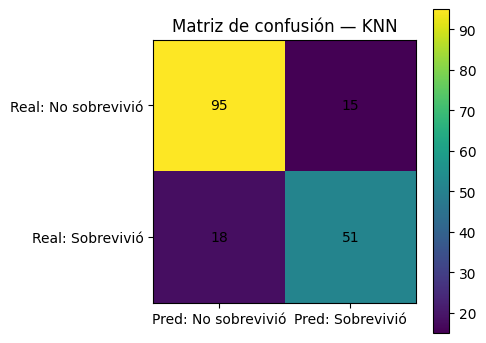

Árbol de decisión


,Pred: No sobrevivió,Pred: Sobrevivió
Real: No sobrevivió,99,11
Real: Sobrevivió,26,43


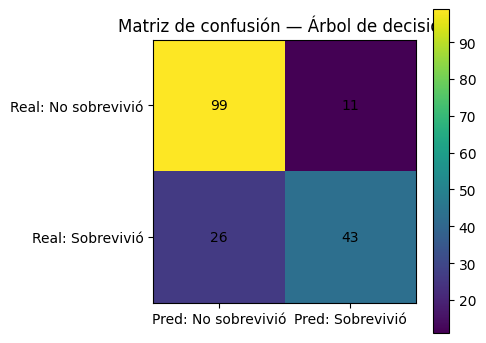

SVM


,Pred: No sobrevivió,Pred: Sobrevivió
Real: No sobrevivió,99,11
Real: Sobrevivió,20,49


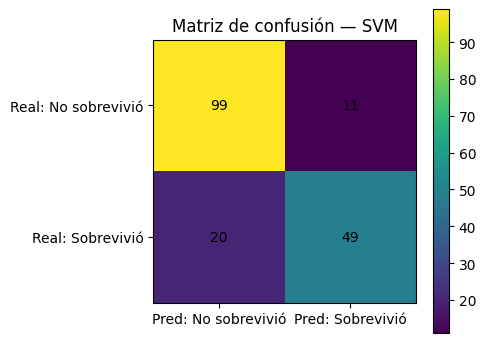

Naive Bayes


,Pred: No sobrevivió,Pred: Sobrevivió
Real: No sobrevivió,93,17
Real: Sobrevivió,21,48


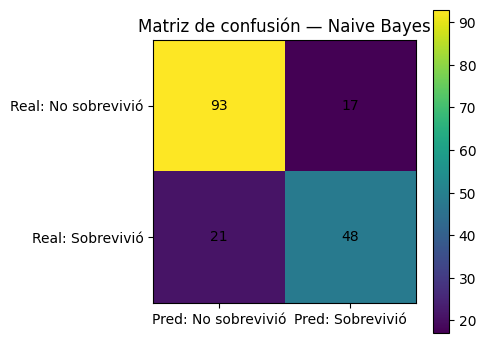

Red Neuronal - 1 capa oculta


,Pred: No sobrevivió,Pred: Sobrevivió
Real: No sobrevivió,98,12
Real: Sobrevivió,26,43


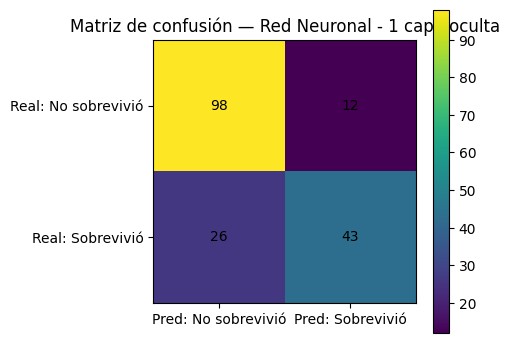

Red Neuronal - 2 capas ocultas


,Pred: No sobrevivió,Pred: Sobrevivió
Real: No sobrevivió,92,18
Real: Sobrevivió,19,50


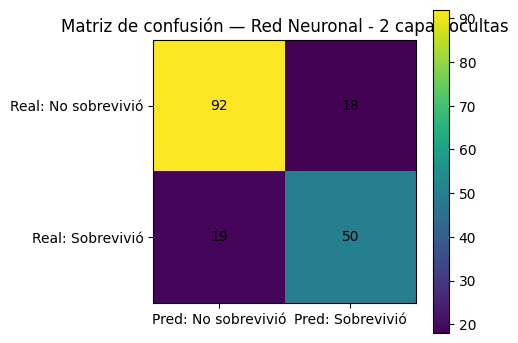

Red Neuronal - 3 capas ocultas


,Pred: No sobrevivió,Pred: Sobrevivió
Real: No sobrevivió,95,15
Real: Sobrevivió,21,48


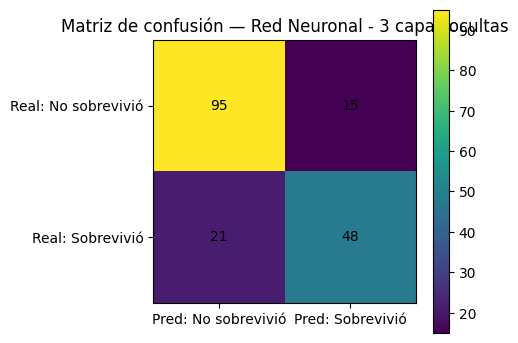

In [26]:
# 9.2 Matrices de confusión
for name, y_pred in model_predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Real: No sobrevivió","Real: Sobrevivió"],
        columns=["Pred: No sobrevivió","Pred: Sobrevivió"]
    )
    print(name)
    display(cm_df)

    fig, ax = plt.subplots(figsize=(5,4))
    image = ax.imshow(cm)
    ax.set_xticks([0, 1], labels=cm_df.columns)
    ax.set_yticks([0, 1], labels=cm_df.index)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_title(f"Matriz de confusión — {name}")
    fig.colorbar(image, ax=ax)
    plt.tight_layout()

    safe = (
        name.lower().replace(" ","_")
        .replace("á","a").replace("ó","o").replace("í","i")
    )
    plt.savefig(FIGURES_DIR / f"confusion_{safe}.png", dpi=160, bbox_inches="tight")
    plt.show()

In [27]:
# 9.3 Reportes de clasificación por modelo
reports_long = []

for name, report_df in classification_reports.items():
    print(f"Reporte — {name}")
    display(report_df)

    tmp = report_df.reset_index().rename(columns={"index":"clase"})
    tmp.insert(0,"Modelo",name)
    reports_long.append(tmp)

classification_reports_df = pd.concat(reports_long, ignore_index=True)
classification_reports_df.to_csv(TABLES_DIR / "classification_reports.csv", index=False)

Reporte — KNN


,precision,recall,f1-score,support
No sobrevivió,0.8407,0.8636,0.8520,110.0000
Sobrevivió,0.7727,0.7391,0.7556,69.0000
accuracy,0.8156,0.8156,0.8156,0.8156
macro avg,0.8067,0.8014,0.8038,179.0000
weighted avg,0.8145,0.8156,0.8148,179.0000


Reporte — Árbol de decisión


,precision,recall,f1-score,support
No sobrevivió,0.7920,0.9000,0.8426,110.0000
Sobrevivió,0.7963,0.6232,0.6992,69.0000
accuracy,0.7933,0.7933,0.7933,0.7933
macro avg,0.7941,0.7616,0.7709,179.0000
weighted avg,0.7937,0.7933,0.7873,179.0000


Reporte — SVM


...

,precision,recall,f1-score,support
No sobrevivió,0.7903,0.8909,0.8376,110.0000
Sobrevivió,0.7818,0.6232,0.6935,69.0000
accuracy,0.7877,0.7877,0.7877,0.7877
macro avg,0.7861,0.7570,0.7656,179.0000
weighted avg,0.7870,0.7877,0.7821,179.0000


Reporte — Red Neuronal - 2 capas ocultas


,precision,recall,f1-score,support
No sobrevivió,0.8288,0.8364,0.8326,110.0000
Sobrevivió,0.7353,0.7246,0.7299,69.0000
accuracy,0.7933,0.7933,0.7933,0.7933
macro avg,0.7821,0.7805,0.7813,179.0000
weighted avg,0.7928,0.7933,0.7930,179.0000


Reporte — Red Neuronal - 3 capas ocultas


,precision,recall,f1-score,support
No sobrevivió,0.8190,0.8636,0.8407,110.0000
Sobrevivió,0.7619,0.6957,0.7273,69.0000
accuracy,0.7989,0.7989,0.7989,0.7989
macro avg,0.7904,0.7796,0.7840,179.0000
weighted avg,0.7970,0.7989,0.7970,179.0000


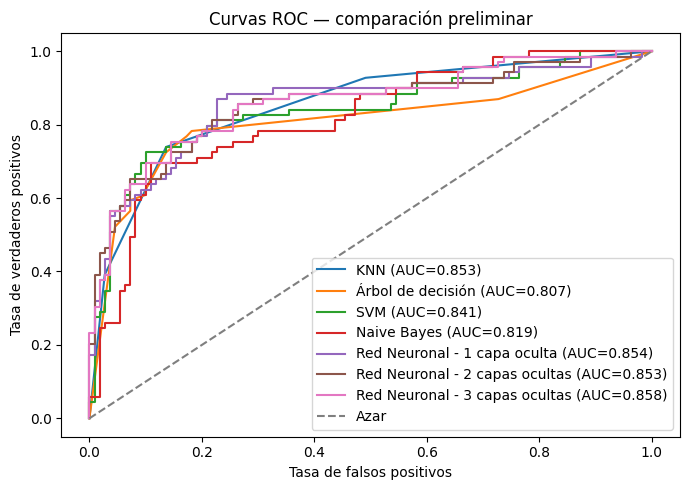

In [28]:
# 9.4 Curvas ROC
plt.figure(figsize=(7,5))
for name, y_score in model_scores.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")

plt.plot([0,1],[0,1], linestyle="--", label="Azar")
plt.title("Curvas ROC — comparación preliminar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_curvas_roc.png", dpi=160, bbox_inches="tight")
plt.show()

In [29]:
# 9.5 Fortalezas, limitaciones y mejores métricas
best_f1_row = metrics_df.loc[metrics_df["F1_test"].idxmax()]
best_recall_row = metrics_df.loc[metrics_df["Recall_test"].idxmax()]
best_auc_row = metrics_df.loc[metrics_df["ROC_AUC_test"].idxmax()]
best_accuracy_row = metrics_df.loc[metrics_df["Accuracy_test"].idxmax()]

display(Markdown(f"""
### Lectura comparativa preliminar

- **Mejor F1:** {best_f1_row['Modelo']} — **{best_f1_row['F1_test']:.3f}**
- **Mejor recall:** {best_recall_row['Modelo']} — **{best_recall_row['Recall_test']:.3f}**
- **Mejor ROC-AUC:** {best_auc_row['Modelo']} — **{best_auc_row['ROC_AUC_test']:.3f}**
- **Mejor accuracy:** {best_accuracy_row['Modelo']} — **{best_accuracy_row['Accuracy_test']:.3f}**

La comparación evidencia que una sola métrica no basta para seleccionar el modelo.
"""))

strengths_limitations = pd.DataFrame({
    "Modelo":[
        "KNN",
        "Árbol de decisión",
        "SVM",
        "Naive Bayes",
        "Red Neuronal - 1 capa oculta",
        "Red Neuronal - 2 capas ocultas",
        "Red Neuronal - 3 capas ocultas"
    ],
    "Fortaleza":[
        "Flexible y basado en similitud local.",
        "Interpretable mediante reglas y estructura jerárquica.",
        "Capaz de construir márgenes y fronteras no lineales.",
        "Probabilístico, simple y computacionalmente eficiente.",
        "Arquitectura MLP relativamente simple con capacidad no lineal.",
        "Mayor capacidad para aprender representaciones jerárquicas.",
        "Mayor profundidad y capacidad representacional entre las redes evaluadas."
    ],
    "Limitación":[
        "Sensible a escala, ruido y dimensionalidad.",
        "Puede sobreajustar y ser inestable.",
        "Requiere escalado y es menos interpretable.",
        "Supone independencia condicional y forma gaussiana por clase.",
        "Requiere escalado y ajuste iterativo; puede ser menos interpretable.",
        "La complejidad adicional no garantiza una mejor generalización.",
        "Mayor riesgo de sobreajuste y costo computacional sin garantía de mejora."
    ]
})
display(strengths_limitations)
strengths_limitations.to_csv(TABLES_DIR / "fortalezas_limitaciones.csv", index=False)


### Lectura comparativa preliminar

- **Mejor F1:** SVM — **0.760**
- **Mejor recall:** KNN — **0.739**
- **Mejor ROC-AUC:** Red Neuronal - 3 capas ocultas — **0.858**
- **Mejor accuracy:** SVM — **0.827**

La comparación evidencia que una sola métrica no basta para seleccionar el modelo.


,Modelo,Fortaleza,Limitación
0,KNN,Flexible y basado en similitud local.,"Sensible a escala, ruido y dimensionalidad."
1,Árbol de decisión,Interpretable mediante reglas y estructura jer...,Puede sobreajustar y ser inestable.
2,SVM,Capaz de construir márgenes y fronteras no lin...,Requiere escalado y es menos interpretable.
3,Naive Bayes,"Probabilístico, simple y computacionalmente ef...",Supone independencia condicional y forma gauss...
4,Red Neuronal - 1 capa oculta,Arquitectura MLP relativamente simple con capa...,Requiere escalado y ajuste iterativo; puede se...
5,Red Neuronal - 2 capas ocultas,Mayor capacidad para aprender representaciones...,La complejidad adicional no garantiza una mejo...
6,Red Neuronal - 3 capas ocultas,Mayor profundidad y capacidad representacional...,Mayor riesgo de sobreajuste y costo computacio...


# 10. Conclusiones preliminares

La siguiente celda genera una síntesis a partir de los resultados de la ejecución actual, evitando conclusiones desconectadas de la evidencia.

In [30]:
best_f1_model = best_f1_row["Modelo"]
best_recall_model = best_recall_row["Modelo"]
best_auc_model = best_auc_row["Modelo"]

if best_f1_model == best_recall_model == best_auc_model:
    comparison_sentence = (
        f"{best_f1_model} lidera F1, recall y ROC-AUC, por lo que aparece como "
        "el candidato preliminar más consistente."
    )
else:
    comparison_sentence = (
        "No existe un ganador absoluto: "
        f"{best_f1_model} lidera F1, {best_recall_model} lidera recall y "
        f"{best_auc_model} lidera ROC-AUC. La elección depende del objetivo operativo."
    )

display(Markdown(f"""
### Conclusiones de la Fase 3

1. El problema quedó formulado como una clasificación binaria de `survived` con siete variables predictoras seleccionadas para evitar redundancia y fuga de información.
2. El EDA evidenció diferencias importantes en supervivencia según `sex` y `pclass`, además de valores faltantes relevantes en `age` y especialmente en `deck`.
3. La preparación se implementó dentro de pipelines, de modo que imputación, codificación y escalado se ajustan con entrenamiento y dentro de cada partición de validación.
4. Los siete modelos (KNN, árbol de decisión, SVM, Naive Bayes y tres arquitecturas MLP) se ajustaron sobre el mismo conjunto de entrenamiento y se evaluaron bajo una estrategia común de validación cruzada estratificada.
5. En prueba, el mejor F1 fue **{best_f1_row['F1_test']:.3f}** ({best_f1_model}); el mejor recall fue **{best_recall_row['Recall_test']:.3f}** ({best_recall_model}); y el mejor ROC-AUC fue **{best_auc_row['ROC_AUC_test']:.3f}** ({best_auc_model}).
6. {comparison_sentence}
7. La comparación entre las redes de una, dos y tres capas permite evaluar si la profundidad adicional mejora la generalización o solo incrementa la complejidad.

**Conclusión general:** el desempeño debe analizarse de manera multidimensional y la decisión final debe sustentarse en métricas, errores observados y el propósito de la clasificación.
"""))


### Conclusiones de la Fase 3

1. El problema quedó formulado como una clasificación binaria de `survived` con siete variables predictoras seleccionadas para evitar redundancia y fuga de información.
2. El EDA evidenció diferencias importantes en supervivencia según `sex` y `pclass`, además de valores faltantes relevantes en `age` y especialmente en `deck`.
3. La preparación se implementó dentro de pipelines, de modo que imputación, codificación y escalado se ajustan con entrenamiento y dentro de cada partición de validación.
4. Los siete modelos (KNN, árbol de decisión, SVM, Naive Bayes y tres arquitecturas MLP) se ajustaron sobre el mismo conjunto de entrenamiento y se evaluaron bajo una estrategia común de validación cruzada estratificada.
5. En prueba, el mejor F1 fue **0.760** (SVM); el mejor recall fue **0.739** (KNN); y el mejor ROC-AUC fue **0.858** (Red Neuronal - 3 capas ocultas).
6. No existe un ganador absoluto: SVM lidera F1, KNN lidera recall y Red Neuronal - 3 capas ocultas lidera ROC-AUC. La elección depende del objetivo operativo.
7. La comparación entre las redes de una, dos y tres capas permite evaluar si la profundidad adicional mejora la generalización o solo incrementa la complejidad.

**Conclusión general:** el desempeño debe analizarse de manera multidimensional y la decisión final debe sustentarse en métricas, errores observados y el propósito de la clasificación.


# 11. Referencias

## Material docente

Ruete, D. (2026a). *Árboles de decisión* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Ruete, D. (2026b). *k-Nearest Neighbors (k-NN)* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Ruete, D. (2026c). *Máquinas de Vectores de Soporte (SVM)* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Ruete, D. (2026d). *Naive Bayes* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Ruete, D. (2026e). *Redes Neuronales* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

## Documentación técnica oficial

Scikit-learn developers. (n.d.-a). *Pipeline*. Scikit-learn documentation. Recuperado el 18 de agosto de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

Scikit-learn developers. (n.d.-b). *Metrics and scoring: Quantifying the quality of predictions*. Scikit-learn documentation. Recuperado el 18 de agosto de 2026, de https://scikit-learn.org/stable/modules/model_evaluation.html

Scikit-learn developers. (n.d.-c). *Nearest neighbors*. Scikit-learn documentation. Recuperado el 18 de agosto de 2026, de https://scikit-learn.org/stable/modules/neighbors.html

Scikit-learn developers. (n.d.-d). *Support vector machines*. Scikit-learn documentation. Recuperado el 18 de agosto de 2026, de https://scikit-learn.org/stable/modules/svm.html

Scikit-learn developers. (n.d.-e). *MLPClassifier*. Scikit-learn documentation. Recuperado el 20 de agosto de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

## Fuente académica complementaria

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*. Springer. https://doi.org/10.1007/978-3-031-38747-0

# 12. Anexos y evidencias exportables

Al ejecutar el notebook se crea `resultados_fase3/` con:

- tablas comparativas de métricas;
- mejores hiperparámetros;
- reportes de clasificación;
- fortalezas y limitaciones;
- comparación específica de las tres redes neuronales;
- figuras del EDA;
- selección de `k`;
- visualización del árbol;
- matrices de confusión;
- curvas ROC.

Estas evidencias pueden incorporarse al informe como anexos manteniendo correspondencia directa con el notebook.

In [31]:
# 12.1 Inventario de evidencias
generated_files = sorted(
    str(path) for path in RESULTS_DIR.rglob("*") if path.is_file()
)
for path in generated_files:
    print(" -", path)
print(f"Total de archivos exportados: {len(generated_files)}")

 - resultados_fase3/figuras/01_distribucion_clases.png
 - resultados_fase3/figuras/02_supervivencia_por_sexo.png
 - resultados_fase3/figuras/03_supervivencia_por_pclass.png
 - resultados_fase3/figuras/04_edad_por_supervivencia.png
 - resultados_fase3/figuras/05_knn_seleccion_k.png
 - resultados_fase3/figuras/06_arbol_decision.png
 - resultados_fase3/figuras/07_curvas_roc.png
 - resultados_fase3/figuras/confusion_arbol_de_decision.png
 - resultados_fase3/figuras/confusion_knn.png
 - resultados_fase3/figuras/confusion_naive_bayes.png
 - resultados_fase3/figuras/confusion_red_neuronal_-_1_capa_oculta.png
 - resultados_fase3/figuras/confusion_red_neuronal_-_2_capas_ocultas.png
 - resultados_fase3/figuras/confusion_red_neuronal_-_3_capas_ocultas.png
 - resultados_fase3/figuras/confusion_svm.png
 - resultados_fase3/tablas/classification_reports.csv
 - resultados_fase3/tablas/comparacion_redes_neuronales.csv
 - resultados_fase3/tablas/fortalezas_limitaciones.csv
 - resultados_fase3/tablas/hip